In [ ]:
import sys, os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_track_list_1 = [
    ("af3_iptm_batch_mean","af3_iptm","af3 iptm"),
    ("af3_ptm_batch_mean","af3_ptm","af3 ptm"),
    ("dist_to_ref_seqs_min_batch_mean","dist_to_ref_seqs_min","dist to ref seqs min"),
    ("petase_metrics_acylox_oxh1bbN_batch_mean","petase_metrics_acylox_oxh1bbN","petase metrics acylox oxh1bbN"),
    ("petase_metrics_acylox_oxh2bbN_batch_mean","petase_metrics_acylox_oxh2bbN","petase metrics acylox oxh2bbN"),
    ("petase_metrics_hisNE2_esterox_batch_mean","petase_metrics_hisNE2_esterox","petase metrics hisNE2 esterox"),
    ("petase_metrics_hisNE2_serOG_batch_mean","petase_metrics_hisNE2_serOG","petase metrics hisNE2 serOG"),
    ("petase_metrics_his_ser_angle_batch_mean","petase_metrics_his_ser_angle","petase metrics his ser angle"),
    ("petase_metrics_ligand_rmsd_batch_mean","petase_metrics_ligand_rmsd","petase metrics ligand rmsd"),
    ("experimental_predictor_mu_batch_mean","experimental_predictor_mu","experimental predictor mu"),
    ("reward", "reward","reward")
]

def plot_metrics(run_data, label, ax, to_track=metrics_to_track_list_1):
    """    
    Plot the metrics from the run data.
    """
    # setup subplots to track all metrics with respect to mean

    for i, x in enumerate(to_track):
        metric, title, description = x
        if metric in run_data.columns:
            sns.lineplot(data=run_data, x="step", y=metric, ax=ax[i//3, i%3], label=label, )
            ax[i//3, i%3].set_title(f"{description}")
            ax[i//3, i%3].set_xlabel("step")
            ax[i//3, i%3].set_ylabel(title)



### track clickase run data

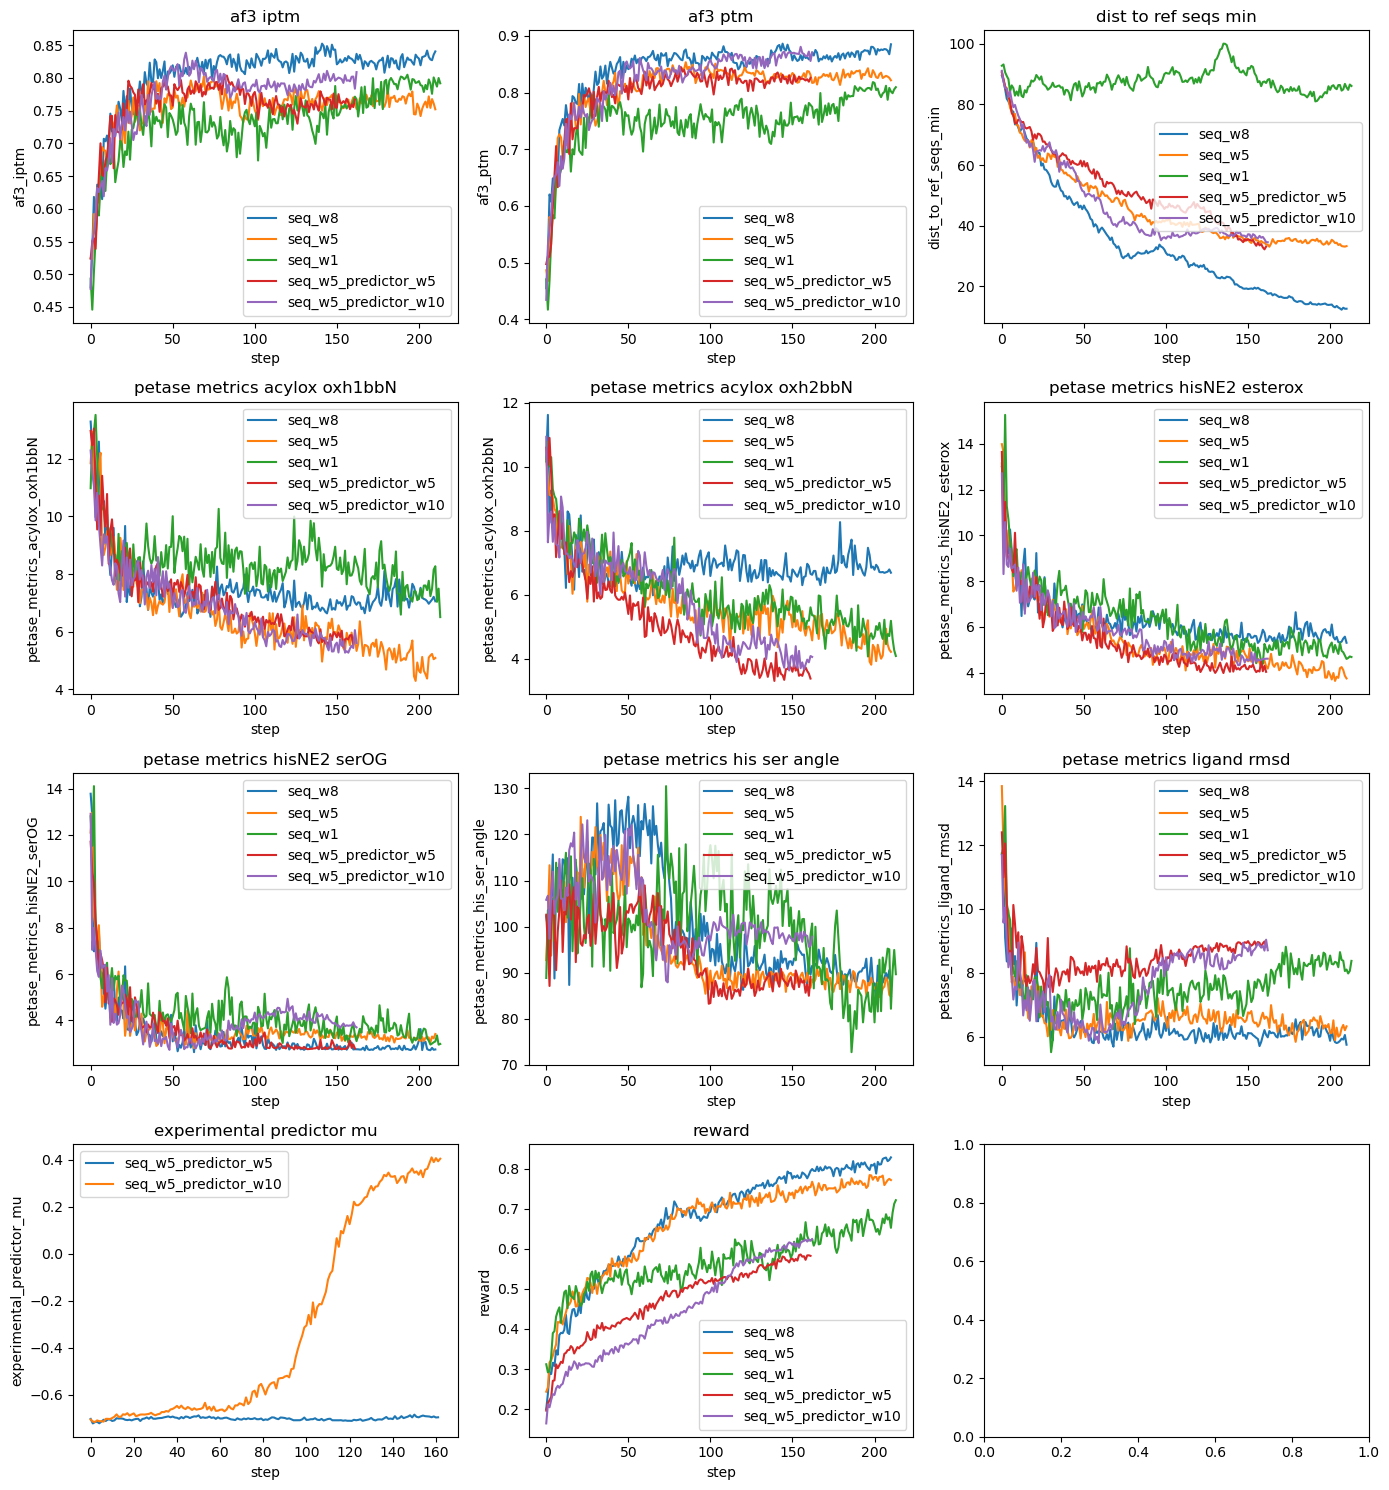

In [61]:
fig, ax = plt.subplots(4,3,figsize=(14, 15))

run_tags = [
    ("new_petase_seq_dist_w8","seq_w8"),
    ("new_petase_seq_dist_w5","seq_w5"),
    ("new_petase_seq_dist_w1","seq_w1"),
    ("new_petase_predictor_w5","seq_w5_predictor_w5"),
    ("new_petase_predictor_w10","seq_w5_predictor_w10"),

]

for tag, label in run_tags:
    run_data = pd.read_csv(f"/home/jgershon/projects/itopt/policy_mpnn/{tag}/{tag}_train_metrics.csv")

    plot_metrics(run_data, label, ax)



plt.tight_layout()


In [8]:
run_data.columns

Index(['step', 'runtime', 'af3_has_clash_batch_mean',
       'af3_has_clash_batch_min', 'af3_has_clash_batch_max',
       'af3_iptm_batch_mean', 'af3_iptm_batch_min', 'af3_iptm_batch_max',
       'af3_ptm_batch_mean', 'af3_ptm_batch_min', 'af3_ptm_batch_max',
       'af3_ranking_score_batch_mean', 'af3_ranking_score_batch_min',
       'af3_ranking_score_batch_max', 'af3_fraction_disordered_batch_mean',
       'af3_fraction_disordered_batch_min',
       'af3_fraction_disordered_batch_max',
       'petase_metrics_acylox_oxh1bbN_batch_mean',
       'petase_metrics_acylox_oxh1bbN_batch_min',
       'petase_metrics_acylox_oxh1bbN_batch_max',
       'petase_metrics_acylox_oxh2bbN_batch_mean',
       'petase_metrics_acylox_oxh2bbN_batch_min',
       'petase_metrics_acylox_oxh2bbN_batch_max',
       'petase_metrics_hisNE2_esterox_batch_mean',
       'petase_metrics_hisNE2_esterox_batch_min',
       'petase_metrics_hisNE2_esterox_batch_max',
       'petase_metrics_hisNE2_serOG_batch_mean',
    